In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm
from windrose import WindroseAxes

In [2]:
dpw_final = pd.read_csv("final PM data/dpw_final_pm25.csv")
pema_final = pd.read_csv("final PM data/pema_final_pm25.csv")
pha_final = pd.read_csv("final PM data/pha_final_pm25.csv")

## DPW EDA

In [3]:
dpw_final.head()

,datetime_utc,rh,temp,pm25,ws,wd,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin,pm_lag1_bin
0,2025-01-02 06:00:00+00:00,58.840000,4.361667,0.494283,9.30,270.0,9.300000,1.708382e-15,6,1.000000,6.123234e-17,0.399550,0.464817,0.442483,0.841567,0,0.0
1,2025-01-02 07:00:00+00:00,55.430000,4.113333,0.694683,5.60,260.0,5.514923,9.724298e-01,7,0.965926,-2.588190e-01,0.494283,0.399550,0.464817,0.478867,0,0.0
2,2025-01-02 08:00:00+00:00,52.586667,3.908333,0.886617,5.70,280.0,5.613404,-9.897946e-01,8,0.866025,-5.000000e-01,0.694683,0.494283,0.399550,0.458833,0,0.0
3,2025-01-02 09:00:00+00:00,50.208333,3.943333,0.952167,7.20,290.0,6.765787,-2.462545e+00,9,0.707107,-7.071068e-01,0.886617,0.694683,0.494283,0.442483,0,0.0
4,2025-01-02 10:00:00+00:00,49.291667,4.011667,0.969433,4.45,260.0,4.382395,7.727344e-01,10,0.500000,-8.660254e-01,0.952167,0.886617,0.694683,0.464817,0,0.0


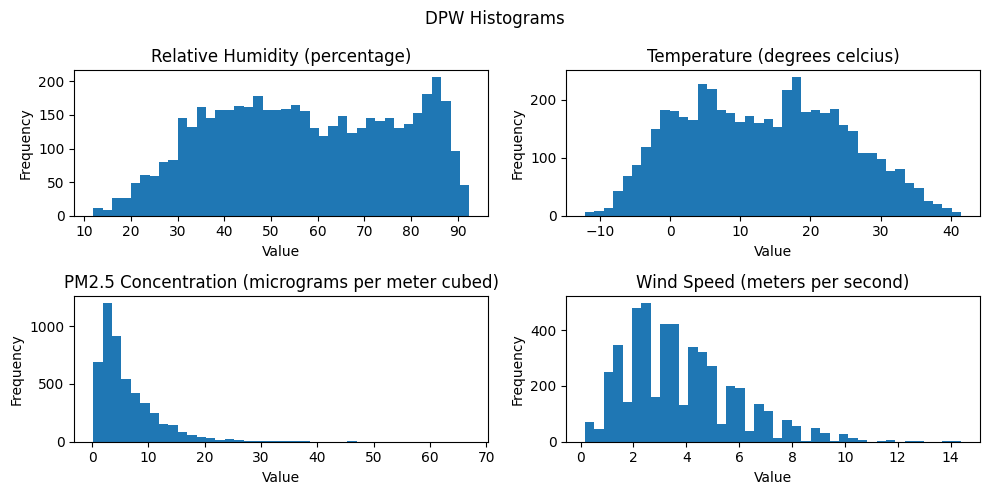

In [4]:
#plots for histograms of meteorologic variables plus pm2.5
cols = ["rh", "temp", "pm25", "ws"]
labels = ["Relative Humidity (percentage)", "Temperature (degrees celcius)", "PM2.5 Concentration (micrograms per meter cubed)", "Wind Speed (meters per second)"]
fig, axes = plt.subplots(2, 2, figsize=(10,5))
axes = axes.flatten()

for i in range(len(cols)):
    axes[i].hist(dpw_final[cols[i]], bins=40)
    axes[i].set_title(labels[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

fig.suptitle("DPW Histograms")
plt.tight_layout()

plt.savefig("eda plots/DPW histograms.png")
plt.show()

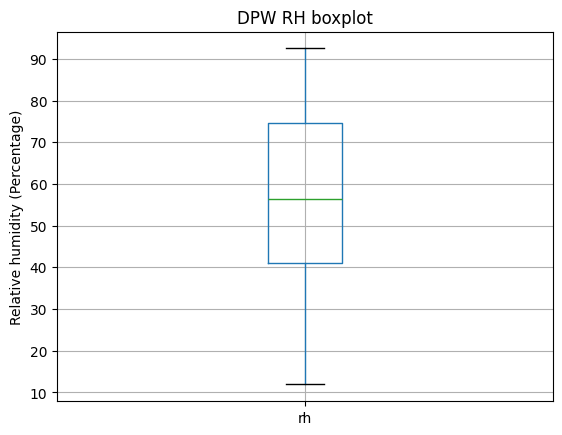

count    4938.000000
mean       57.317448
std        19.741511
min        11.888333
25%        41.129167
50%        56.400833
75%        74.703333
max        92.488333
Name: rh, dtype: float64

In [5]:
#relative humidity boxplot
dpw_final[["rh"]].boxplot()
plt.title("DPW RH boxplot")
plt.ylabel("Relative humidity (Percentage)")

plt.savefig("eda plots/DPW RH boxplot.png")
plt.show()
dpw_final["rh"].describe()

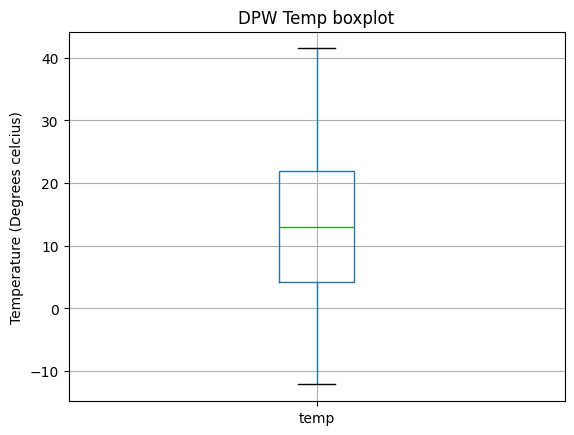

count    4938.000000
mean       13.272006
std        11.229787
min       -12.121667
25%         4.220833
50%        13.071667
75%        21.982500
max        41.483333
Name: temp, dtype: float64

In [6]:
#temperature boxplot
dpw_final[["temp"]].boxplot()
plt.title("DPW Temp boxplot")
dpw_final["temp"].describe()
plt.ylabel("Temperature (Degrees celcius)")

plt.savefig("eda plots/DPW Temp boxplot.png")
plt.show()
dpw_final["temp"].describe()

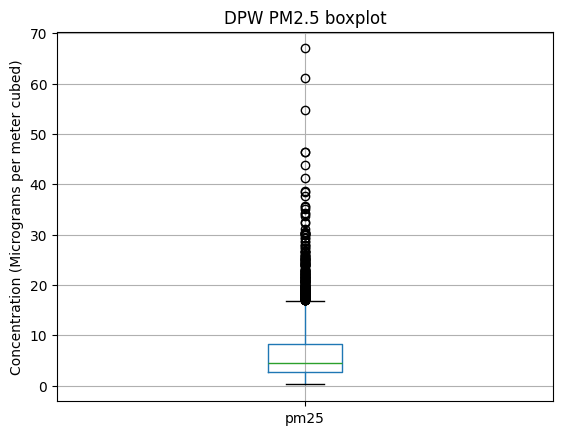

count    4938.000000
mean        6.221975
std         5.356118
min         0.215217
25%         2.642762
50%         4.521225
75%         8.343917
max        66.981817
Name: pm25, dtype: float64

In [7]:
#pm2.5 concentration boxlpot
dpw_final[["pm25"]].boxplot()
plt.title("DPW PM2.5 boxplot")
dpw_final["pm25"].describe()
plt.ylabel("Concentration (Micrograms per meter cubed)")

plt.savefig("eda plots/DPW PM2.5 boxplot.png")
plt.show()
dpw_final["pm25"].describe()

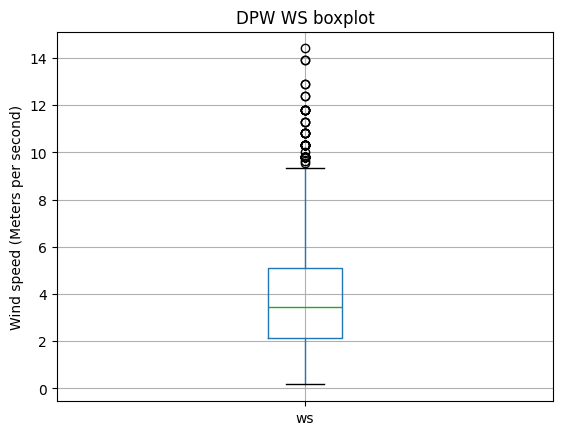

count    4938.000000
mean        3.775668
std         2.078220
min         0.166667
25%         2.150000
50%         3.450000
75%         5.100000
max        14.400000
Name: ws, dtype: float64

In [8]:
#wind speed boxplot
dpw_final[["ws"]].boxplot()
plt.title("DPW WS boxplot")
dpw_final["ws"].describe()
plt.ylabel("Wind speed (Meters per second)")

plt.savefig("eda plots/DPW WS boxplot.png")
plt.show()
dpw_final["ws"].describe()

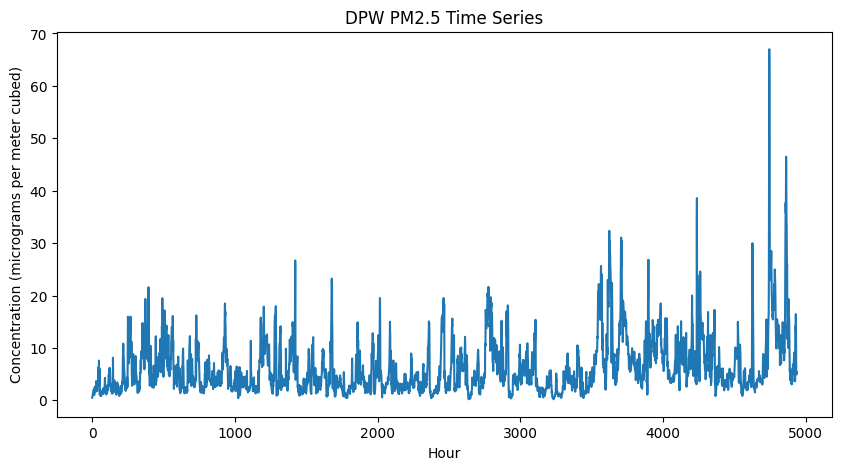

In [9]:
#time series for pm2.5
dpw_final["pm25"].plot(figsize=(10,5), title="DPW PM2.5 Time Series")
plt.xlabel("Hour")
plt.ylabel("Concentration (micrograms per meter cubed)")

plt.savefig("eda plots/DPW PM2.5 time series.png")
plt.show()

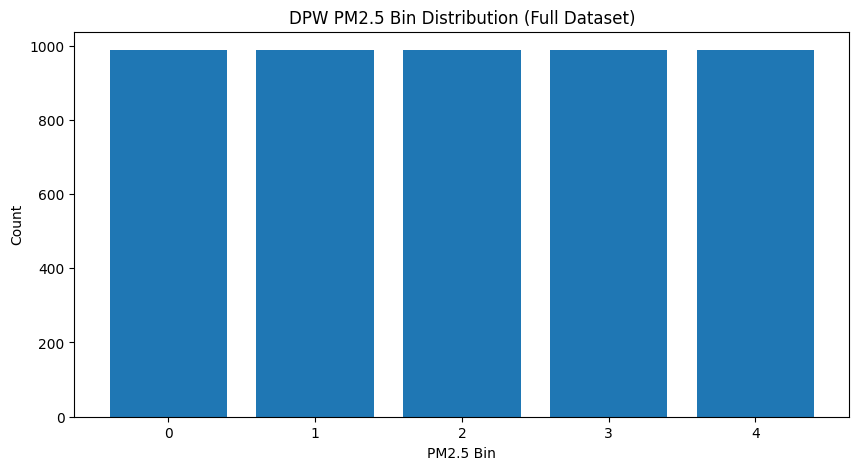

In [10]:
#PM2.5 bin distribution. For the time series we expect each bin to have equal counts
bin_counts = dpw_final["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(bin_counts.index, bin_counts.values)

plt.xlabel("PM2.5 Bin")
plt.ylabel("Count")
plt.title("DPW PM2.5 Bin Distribution (Full Dataset)")
plt.xticks(bin_counts.index)

plt.savefig("eda plots/DPW PM2.5 bin distribution (full dataset).png")
plt.show()

In [11]:
#function for adding a "season" feature, used for following visuals
dpw_final["month"] = pd.to_datetime(dpw_final["datetime_utc"]).dt.month
def get_season(m):
    if m in [1, 2]:
        return "JF"
    elif m in [3, 4, 5]:
        return "MAM"
    elif m in [6, 7, 8]:
        return "JJA"

dpw_final["season"] = dpw_final["month"].apply(get_season)

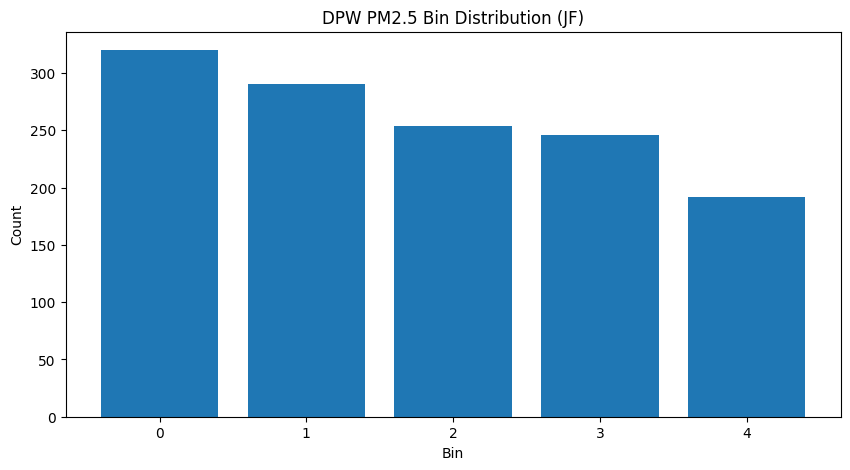

In [12]:
#plotting winter month bin counts
jf_counts = dpw_final[dpw_final["season"] == "JF"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(jf_counts.index, jf_counts.values)
plt.title("DPW PM2.5 Bin Distribution (JF)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(jf_counts.index)

plt.savefig("eda plots/DPW PM2.5 bin distribution (JF).png")
plt.show()

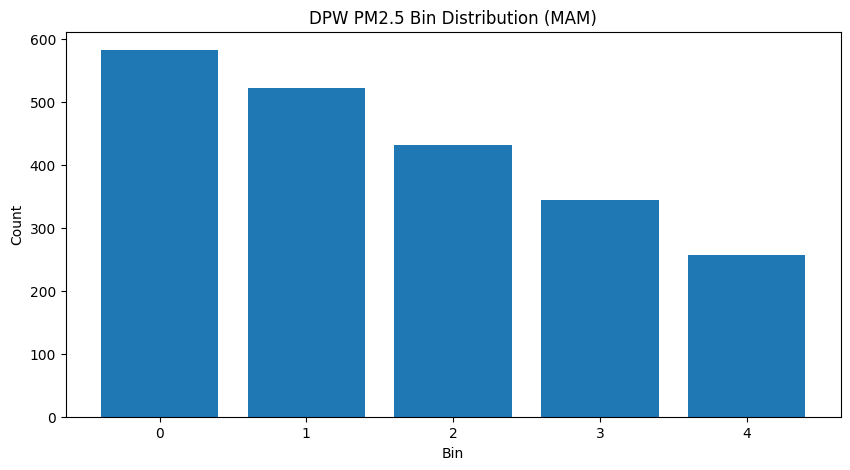

In [13]:
#plotting spring bin counts
mam_counts = dpw_final[dpw_final["season"] == "MAM"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(mam_counts.index, mam_counts.values)
plt.title("DPW PM2.5 Bin Distribution (MAM)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(mam_counts.index)

plt.savefig("eda plots/DPW PM2.5 bin distribution (MAM).png")
plt.show()

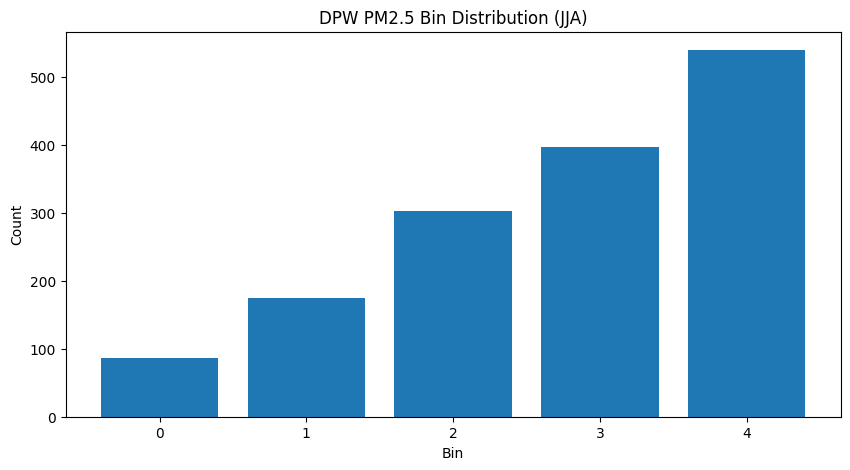

In [14]:
#plotting summer bin counts
jja_counts = dpw_final[dpw_final["season"] == "JJA"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(jja_counts.index, jja_counts.values)
plt.title("DPW PM2.5 Bin Distribution (JJA)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(jja_counts.index)

plt.savefig("eda plots/DPW PM2.5 bin distribution (JJA).png")
plt.show()

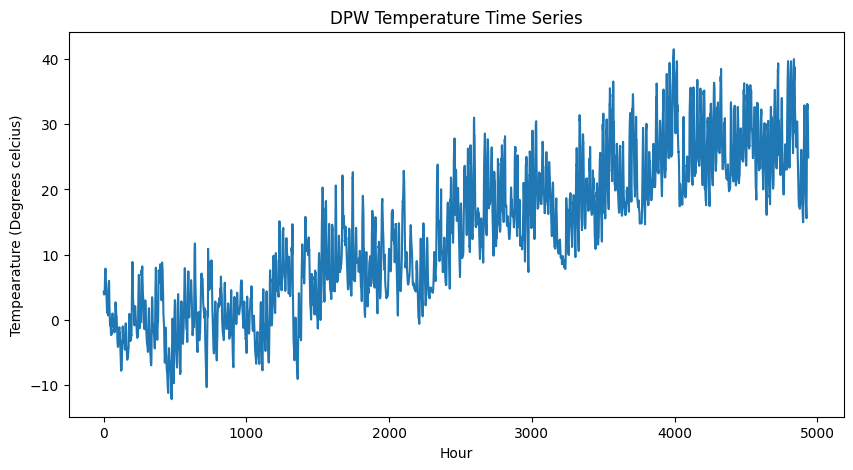

In [15]:
#time series for temperature. Expecting increase as end of data is in summer
dpw_final["temp"].plot(figsize=(10,5), title="DPW Temperature Time Series")
plt.xlabel("Hour")
plt.ylabel("Tempearature (Degrees celcius)")

plt.savefig("eda plots/DPW temperature time series.png")
plt.show()

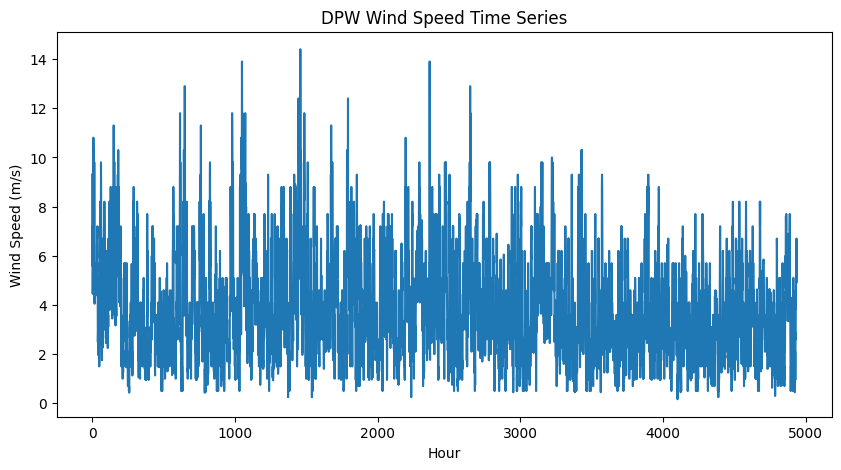

In [16]:
#time series for wind speed
dpw_final["ws"].plot(figsize=(10,5), title="DPW Wind Speed Time Series")
plt.xlabel("Hour")
plt.ylabel("Wind Speed (m/s)")

plt.savefig("eda plots/DPW wind speed time series.png")
plt.show()

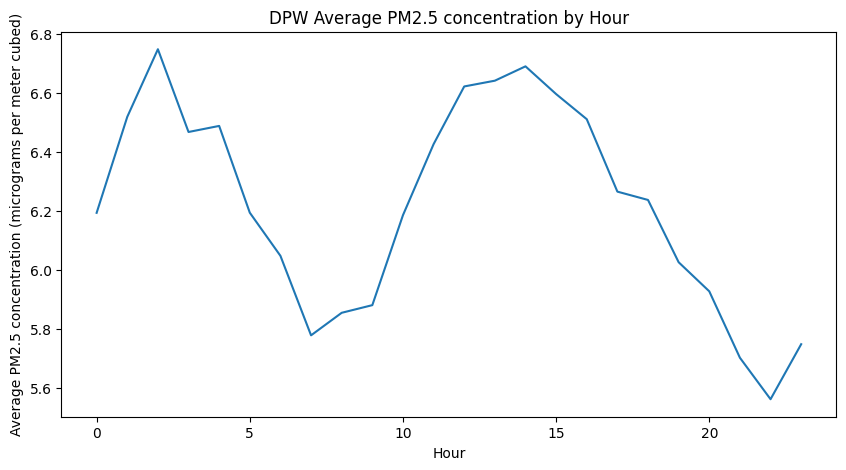

In [17]:
#average hourly PM2.6 concentration
dpw_hourly_pm = dpw_final.groupby("hour")["pm25"].mean()

plt.figure(figsize=(10,5))
dpw_hourly_pm.plot()
plt.title("DPW Average PM2.5 concentration by Hour")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5 concentration (micrograms per meter cubed)")

plt.savefig("eda plots/DPW average hourly PM2.5 concentration.png")
plt.show()

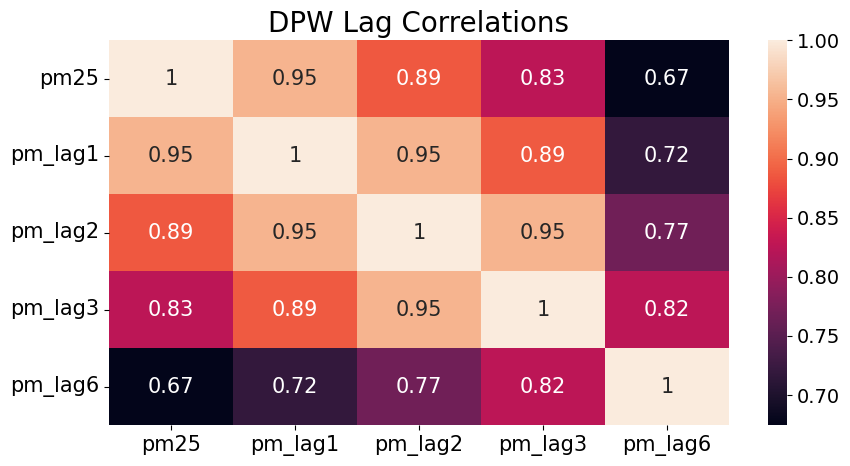

In [18]:
#correlation between various pm lags and pm itself
lags = ["pm25", "pm_lag1", "pm_lag2", "pm_lag3", "pm_lag6"]

plt.figure(figsize=(10,5))
ax = sns.heatmap(dpw_final[lags].corr(), annot=True, annot_kws={"size": 15})
plt.title("DPW Lag Correlations", fontsize=20)
plt.yticks(rotation=0)

ax.tick_params(axis="both", labelsize=15)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.savefig("eda plots/DPW lag correlations.png")
plt.show()

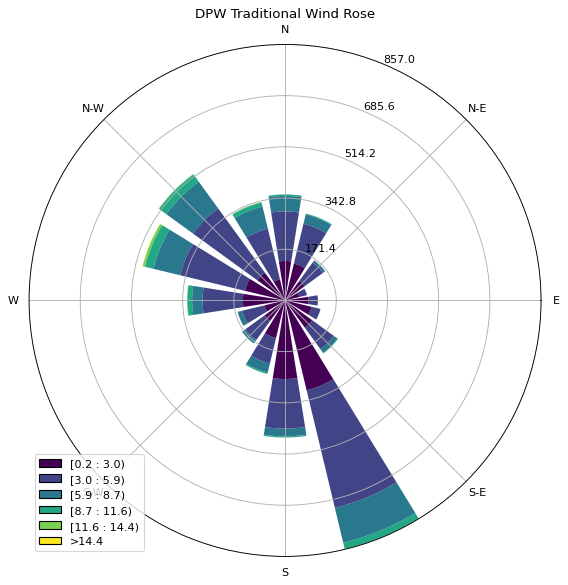

In [19]:
#wind rose
ax = WindroseAxes.from_ax()
ax.bar(dpw_final["wd"], dpw_final["ws"])
plt.title("DPW Traditional Wind Rose")
plt.legend()

plt.savefig("eda plots/DPW traditional wind rose.png")
plt.show()

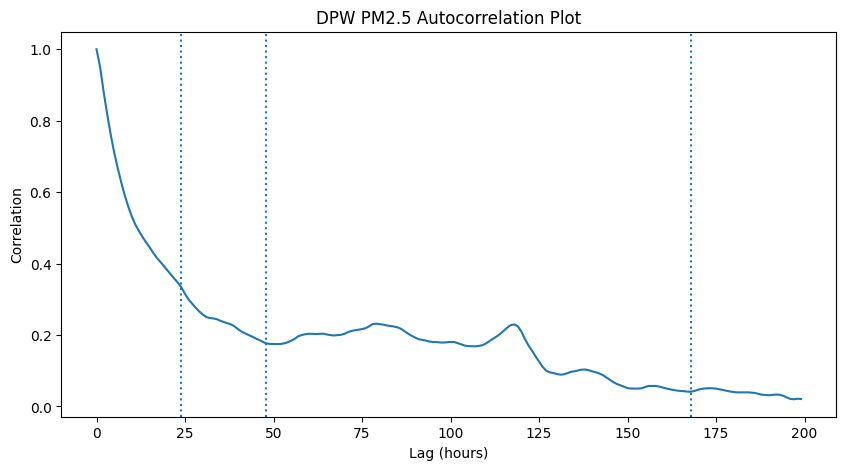

In [20]:
#only want lags over course of about a week here
#plot that was for whole time series did not show that much useful information
lags = range(0, 200)
acf_vals = []
for l in lags:
    val = dpw_final["pm25"].autocorr(lag=l)
    acf_vals.append(val)

plt.figure(figsize=(10,5))
plt.title("DPW PM2.5 Autocorrelation Plot")

#plot lines where correlation may spike
plt.axvline(24, linestyle=":")
plt.axvline(48, linestyle=":")
plt.axvline(168, linestyle=":")

plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")

plt.savefig("eda plots/DPW PM2.5 autocorrelation plot.png")
plt.plot(lags, acf_vals)

## PEMA EDA

In [21]:
pema_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin,pm_lag1_bin
0,2025-01-02 06:00:00+00:00,61.271667,3.978333,288.680000,4.513833,0.045150,4.276054,-1.445701,6,1.000000,6.123234e-17,0.040767,0.049150,0.033750,0.096833,0,0.0
1,2025-01-02 07:00:00+00:00,57.641667,3.725000,289.245000,5.204833,0.052300,4.913976,-1.715556,7,0.965926,-2.588190e-01,0.045150,0.040767,0.049150,0.050633,0,0.0
2,2025-01-02 08:00:00+00:00,53.136667,3.656667,294.898333,5.591833,0.052267,5.072107,-2.354215,8,0.866025,-5.000000e-01,0.052300,0.045150,0.040767,0.047417,0,0.0
3,2025-01-02 09:00:00+00:00,50.996667,3.491667,291.131667,4.624833,0.054683,4.313834,-1.667310,9,0.707107,-7.071068e-01,0.052267,0.052300,0.045150,0.033750,0,0.0
4,2025-01-02 10:00:00+00:00,50.645000,3.486667,284.775000,4.678333,0.061867,4.523643,-1.193087,10,0.500000,-8.660254e-01,0.054683,0.052267,0.052300,0.049150,0,0.0


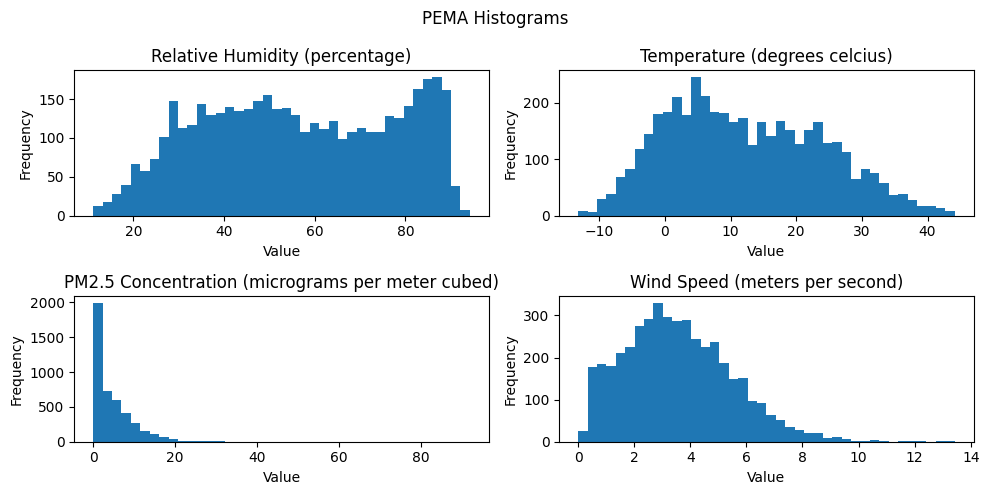

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10,5))
axes = axes.flatten()

for i in range(len(cols)):
    axes[i].hist(pema_final[cols[i]], bins=40)
    axes[i].set_title(labels[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

fig.suptitle("PEMA Histograms")
plt.tight_layout()

plt.savefig("eda plots/PEMA histograms.png")
plt.show()

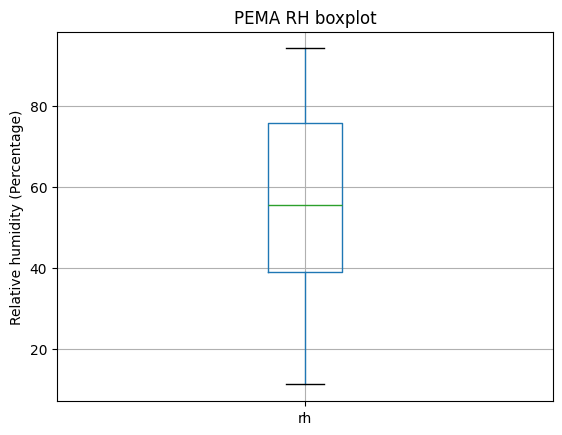

count    4415.000000
mean       56.398223
std        20.971075
min        11.123333
25%        38.960000
50%        55.410000
75%        75.727500
max        94.206667
Name: rh, dtype: float64

In [23]:
pema_final[["rh"]].boxplot()
plt.title("PEMA RH boxplot")
plt.ylabel("Relative humidity (Percentage)")

plt.savefig("eda plots/PEMA RH boxplot.png")
plt.show()
pema_final["rh"].describe()

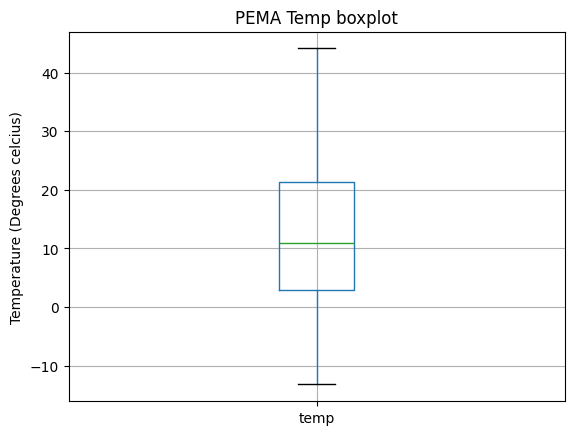

count    4415.000000
mean       12.267033
std        11.761507
min       -13.220000
25%         2.917500
50%        10.956667
75%        21.397500
max        44.140678
Name: temp, dtype: float64

In [24]:
pema_final[["temp"]].boxplot()
plt.title("PEMA Temp boxplot")
pema_final["temp"].describe()
plt.ylabel("Temperature (Degrees celcius)")

plt.savefig("eda plots/PEMA Temp boxplot.png")
plt.show()
pema_final["temp"].describe()

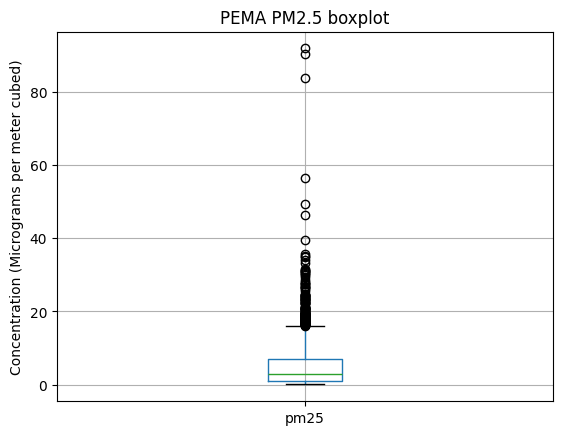

count    4415.000000
mean        4.755634
std         5.615744
min         0.030983
25%         0.854758
50%         2.961983
75%         6.953933
max        91.840267
Name: pm25, dtype: float64

In [25]:
pema_final[["pm25"]].boxplot()
plt.title("PEMA PM2.5 boxplot")
pema_final["pm25"].describe()
plt.ylabel("Concentration (Micrograms per meter cubed)")

plt.savefig("eda plots/PEMA PM2.5 boxplot.png")
plt.show()
pema_final["pm25"].describe()

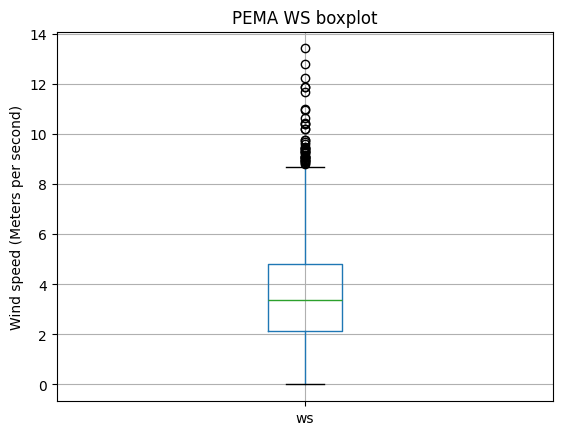

count    4415.000000
mean        3.556752
std         1.916652
min         0.000000
25%         2.134667
50%         3.375833
75%         4.795917
max        13.426833
Name: ws, dtype: float64

In [26]:
pema_final[["ws"]].boxplot()
plt.title("PEMA WS boxplot")
pema_final["ws"].describe()
plt.ylabel("Wind speed (Meters per second)")

plt.savefig("eda plots/PEMA WS boxplot.png")
plt.show()
pema_final["ws"].describe()

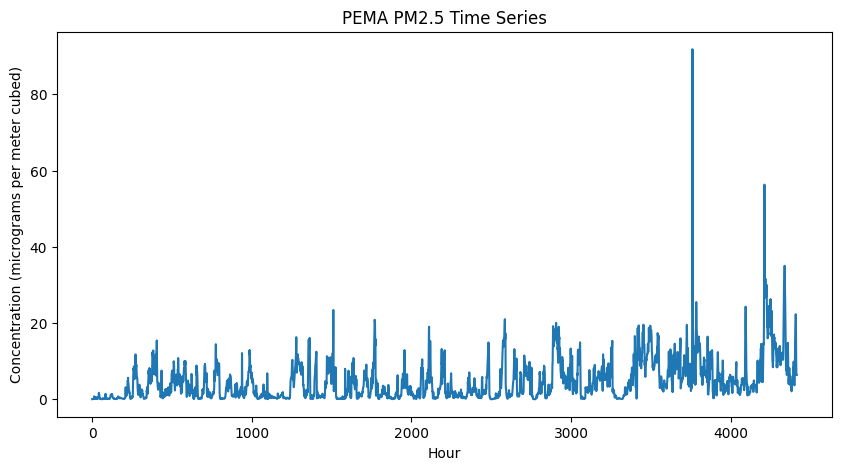

In [27]:
pema_final["pm25"].plot(figsize=(10,5), title="PEMA PM2.5 Time Series")
plt.xlabel("Hour")
plt.ylabel("Concentration (micrograms per meter cubed)")

plt.savefig("eda plots/PEMA PM2.5 time series.png")
plt.show()

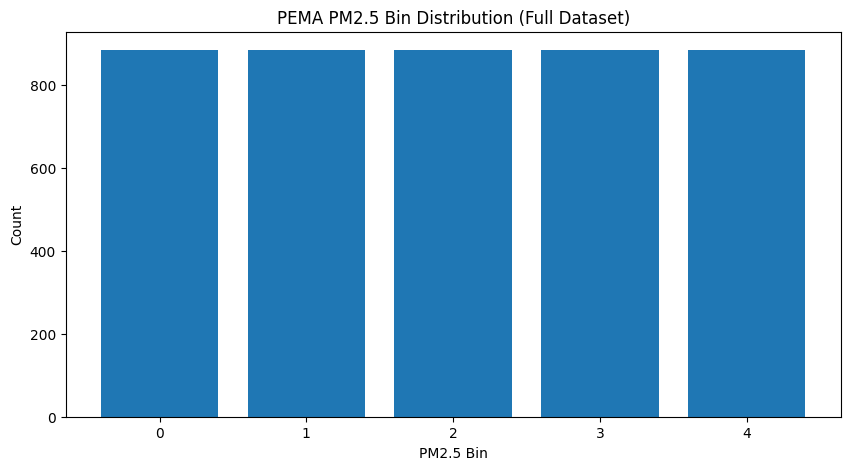

In [28]:
#PM2.5 bin distribution. For the time series we expect each bin to have equal counts
bin_counts = pema_final["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(bin_counts.index, bin_counts.values)

plt.xlabel("PM2.5 Bin")
plt.ylabel("Count")
plt.title("PEMA PM2.5 Bin Distribution (Full Dataset)")
plt.xticks(bin_counts.index)

plt.savefig("eda plots/PEMA PM2.5 bin distribution (full dataset).png")
plt.show()

In [29]:
pema_final["month"] = pd.to_datetime(pema_final["datetime_utc"]).dt.month
pema_final["season"] = pema_final["month"].apply(get_season)

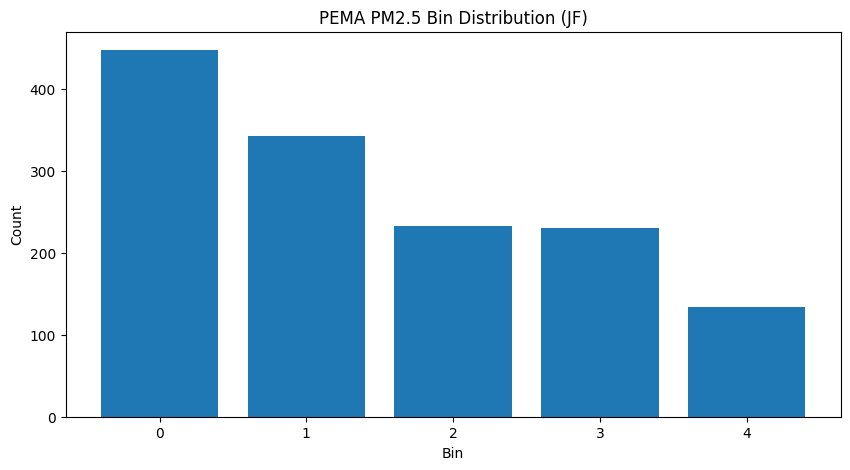

In [30]:
#plotting winter month bin counts
jf_counts = pema_final[pema_final["season"] == "JF"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(jf_counts.index, jf_counts.values)
plt.title("PEMA PM2.5 Bin Distribution (JF)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(jf_counts.index)

plt.savefig("eda plots/PEMA PM2.5 bin distribution (JF).png")
plt.show()

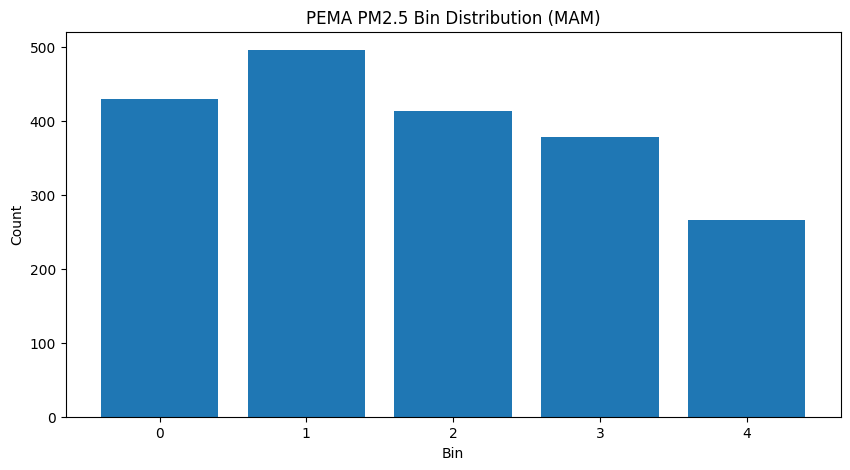

In [31]:
#plotting spring bin counts
mam_counts = pema_final[pema_final["season"] == "MAM"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(mam_counts.index, mam_counts.values)
plt.title("PEMA PM2.5 Bin Distribution (MAM)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(mam_counts.index)

plt.savefig("eda plots/PEMA PM2.5 bin distribution (MAM).png")
plt.show()

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_93918/1615080845.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  jja_counts = pema_final[dpw_final["season"] == "JJA"]["pm25_bin"].value_counts().sort_index()


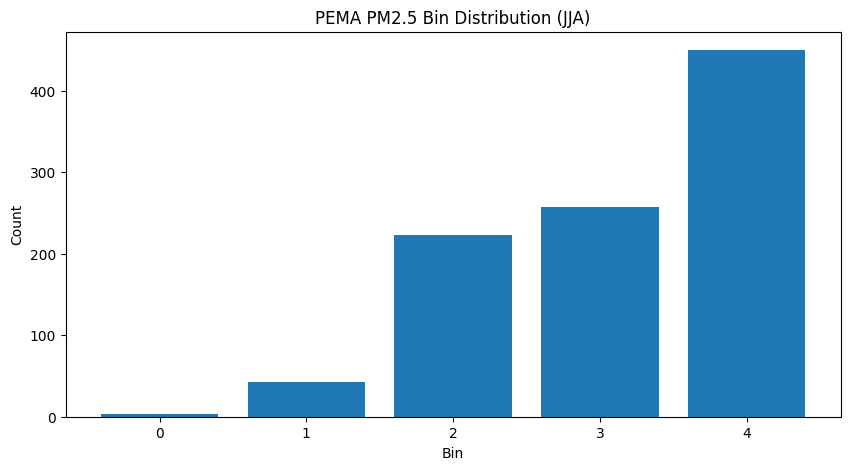

In [32]:
#plotting summer bin counts
jja_counts = pema_final[dpw_final["season"] == "JJA"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(jja_counts.index, jja_counts.values)
plt.title("PEMA PM2.5 Bin Distribution (JJA)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(jja_counts.index)

plt.savefig("eda plots/PEMA PM2.5 bin distribution (JJA).png")
plt.show()

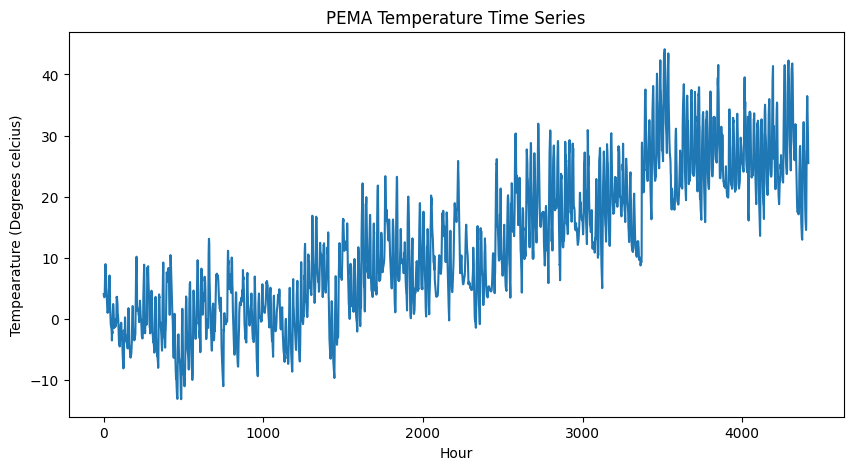

In [33]:
pema_final["temp"].plot(figsize=(10,5), title="PEMA Temperature Time Series")
plt.xlabel("Hour")
plt.ylabel("Tempearature (Degrees celcius)")

plt.savefig("eda plots/PEMA temperature time series.png")
plt.show()

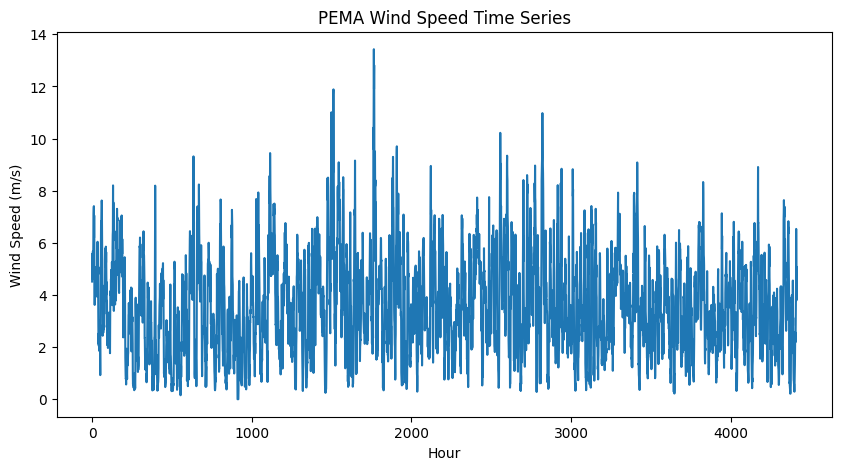

In [34]:
#time series for wind speed
pema_final["ws"].plot(figsize=(10,5), title="PEMA Wind Speed Time Series")
plt.xlabel("Hour")
plt.ylabel("Wind Speed (m/s)")

plt.savefig("eda plots/PEMA wind speed time series.png")
plt.show()

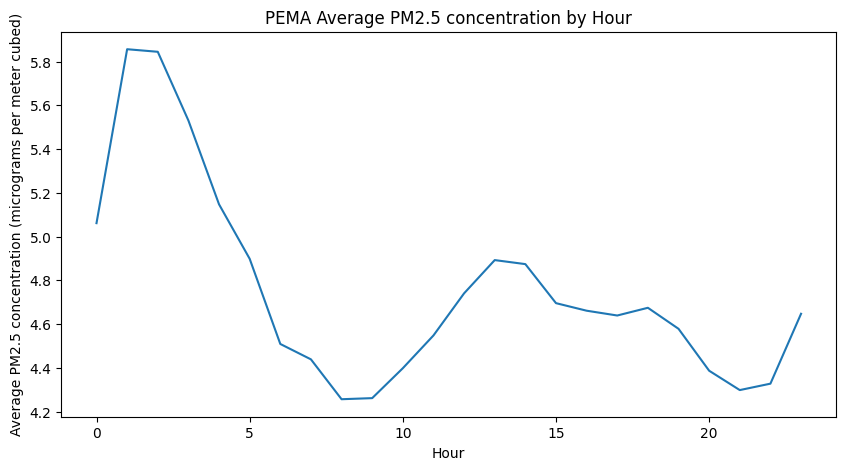

In [35]:
pema_hourly_pm = pema_final.groupby("hour")["pm25"].mean()

plt.figure(figsize=(10,5))
pema_hourly_pm.plot()
plt.title("PEMA Average PM2.5 concentration by Hour")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5 concentration (micrograms per meter cubed)")

plt.savefig("eda plots/PEMA average hourly PM2.5 concentration.png")
plt.show()

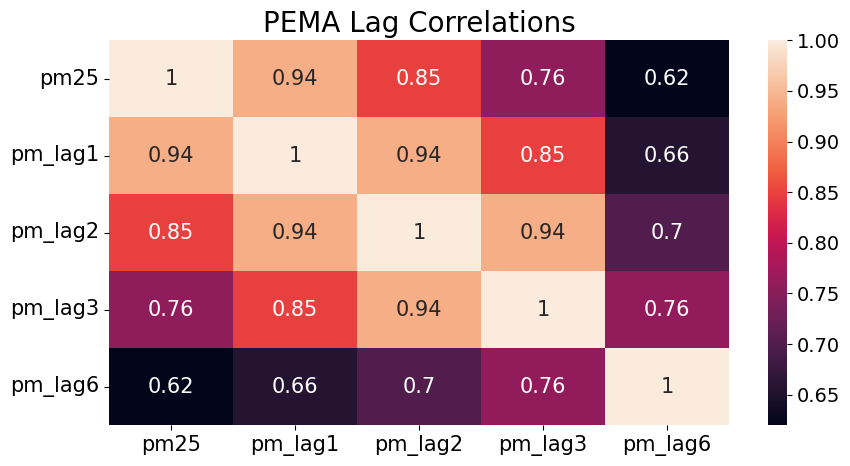

In [36]:
#correlation between various pm lags and pm itself
lags = ["pm25", "pm_lag1", "pm_lag2", "pm_lag3", "pm_lag6"]

plt.figure(figsize=(10,5))
ax = sns.heatmap(pema_final[lags].corr(), annot=True, annot_kws={"size": 15})
plt.title("PEMA Lag Correlations", fontsize=20)
plt.yticks(rotation=0)

ax.tick_params(axis="both", labelsize=15)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.savefig("eda plots/PEMA lag correlations.png")
plt.show()

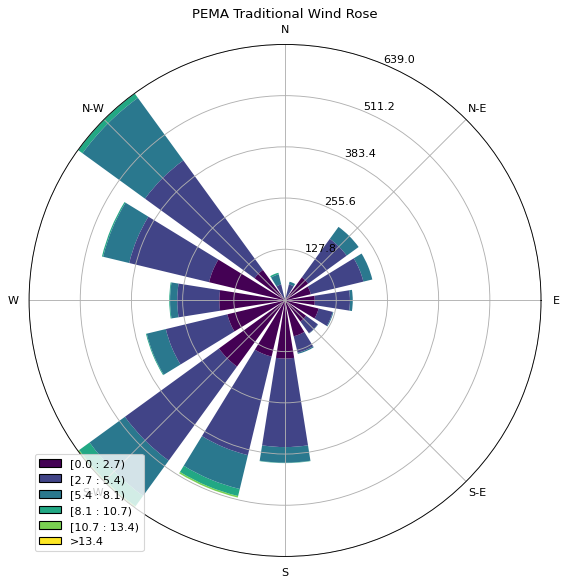

In [37]:
ax = WindroseAxes.from_ax()
ax.bar(pema_final["wd"], pema_final["ws"])
plt.title("PEMA Traditional Wind Rose")
plt.legend()

plt.savefig("eda plots/PEMA traditional wind rose.png")
plt.show()

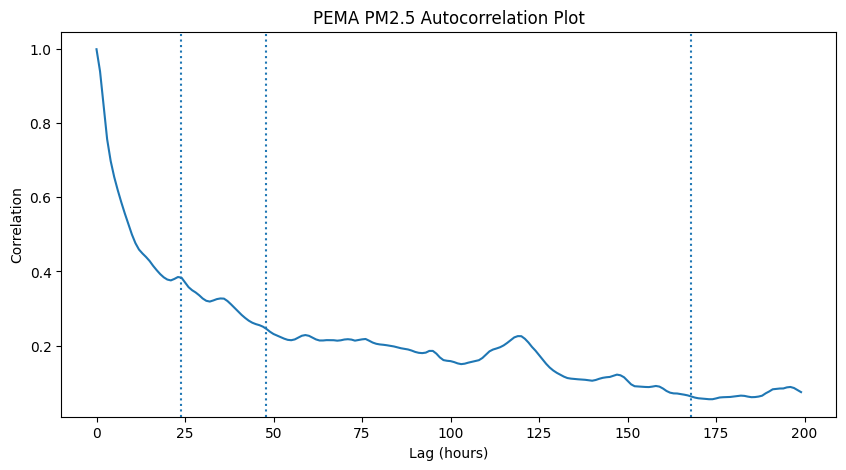

In [38]:
#only want lags over course of about a week here
#plot that was for whole time series did not show that much useful information
lags = range(0, 200)
acf_vals = []
for l in lags:
    val = pema_final["pm25"].autocorr(lag=l)
    acf_vals.append(val)

plt.figure(figsize=(10,5))
plt.title("PEMA PM2.5 Autocorrelation Plot")

#plot lines where correlation may spike
plt.axvline(24, linestyle=":")
plt.axvline(48, linestyle=":")
plt.axvline(168, linestyle=":")

plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")

plt.savefig("eda plots/PEMA PM2.5 autocorrelation plot.png")
plt.plot(lags, acf_vals)

## PHA EDA

In [39]:
pema_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin,pm_lag1_bin,month,season
0,2025-01-02 06:00:00+00:00,61.271667,3.978333,288.680000,4.513833,0.045150,4.276054,-1.445701,6,1.000000,6.123234e-17,0.040767,0.049150,0.033750,0.096833,0,0.0,1,JF
1,2025-01-02 07:00:00+00:00,57.641667,3.725000,289.245000,5.204833,0.052300,4.913976,-1.715556,7,0.965926,-2.588190e-01,0.045150,0.040767,0.049150,0.050633,0,0.0,1,JF
2,2025-01-02 08:00:00+00:00,53.136667,3.656667,294.898333,5.591833,0.052267,5.072107,-2.354215,8,0.866025,-5.000000e-01,0.052300,0.045150,0.040767,0.047417,0,0.0,1,JF
3,2025-01-02 09:00:00+00:00,50.996667,3.491667,291.131667,4.624833,0.054683,4.313834,-1.667310,9,0.707107,-7.071068e-01,0.052267,0.052300,0.045150,0.033750,0,0.0,1,JF
4,2025-01-02 10:00:00+00:00,50.645000,3.486667,284.775000,4.678333,0.061867,4.523643,-1.193087,10,0.500000,-8.660254e-01,0.054683,0.052267,0.052300,0.049150,0,0.0,1,JF


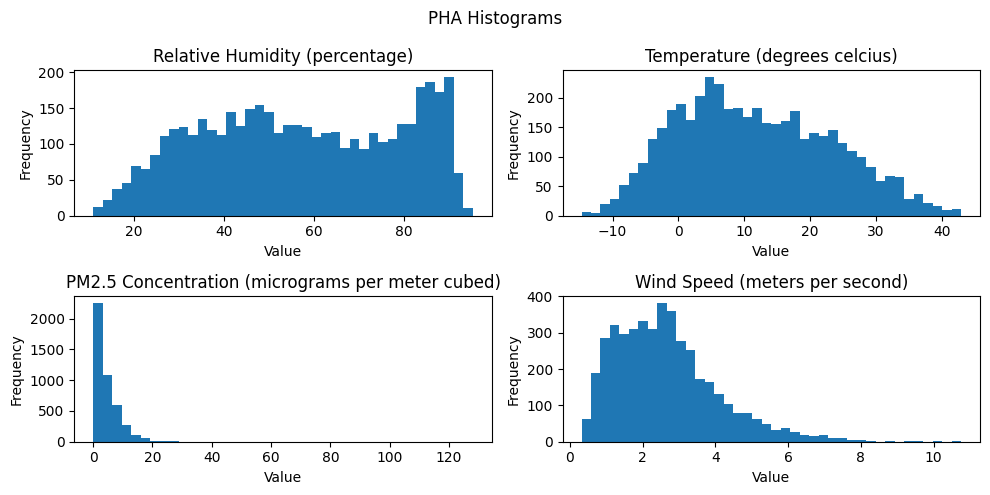

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(10,5))
axes = axes.flatten()

for i in range(len(cols)):
    axes[i].hist(pha_final[cols[i]], bins=40)
    axes[i].set_title(labels[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

fig.suptitle("PHA Histograms")
plt.tight_layout()

plt.savefig("eda plots/PHA histograms.png")
plt.show()

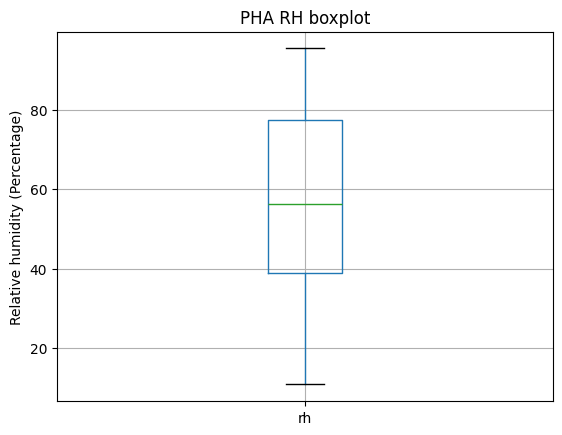

count    4401.000000
mean       57.199253
std        21.852631
min        10.908333
25%        38.973333
50%        56.366667
75%        77.531667
max        95.411667
Name: rh, dtype: float64

In [41]:
pha_final[["rh"]].boxplot()
plt.title("PHA RH boxplot")
plt.ylabel("Relative humidity (Percentage)")

plt.savefig("eda plots/PHA RH boxplot.png")
plt.show()
pha_final["rh"].describe()

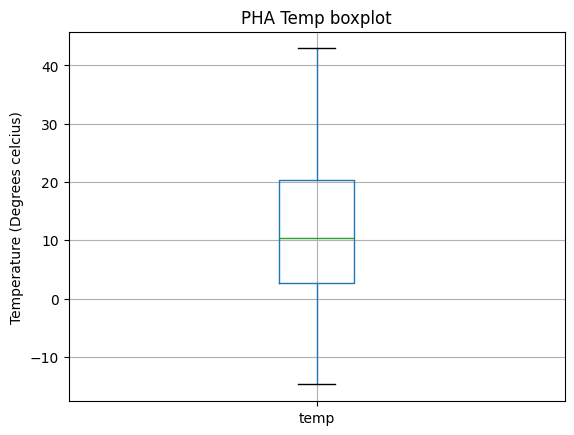

count    4401.000000
mean       11.684991
std        11.637207
min       -14.710000
25%         2.665000
50%        10.403333
75%        20.390000
max        42.891525
Name: temp, dtype: float64

In [42]:
pha_final[["temp"]].boxplot()
plt.title("PHA Temp boxplot")
pha_final["temp"].describe()
plt.ylabel("Temperature (Degrees celcius)")

plt.savefig("eda plots/PHA Temp boxplot.png")
plt.show()
pha_final["temp"].describe()

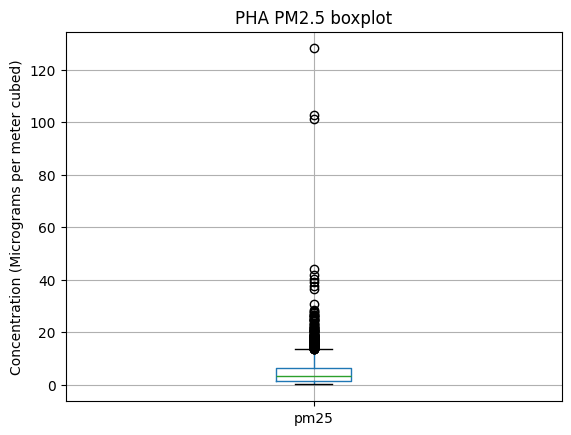

count    4401.000000
mean        4.683284
std         5.140638
min         0.119367
25%         1.492800
50%         3.245600
75%         6.404100
max       128.021000
Name: pm25, dtype: float64

In [43]:
pha_final[["pm25"]].boxplot()
plt.title("PHA PM2.5 boxplot")
pha_final["pm25"].describe()
plt.ylabel("Concentration (Micrograms per meter cubed)")

plt.savefig("eda plots/PHA PM2.5 boxplot.png")
plt.show()
pha_final["pm25"].describe()

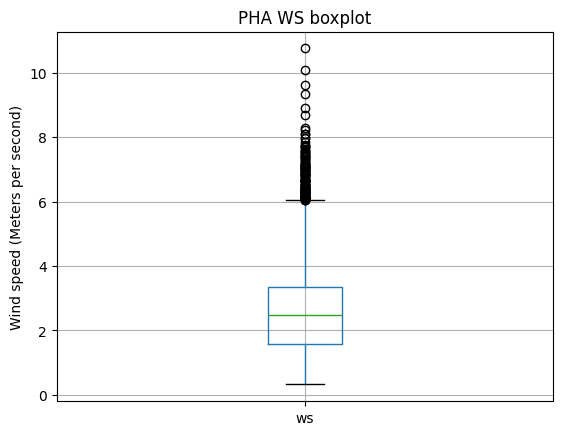

count    4401.000000
mean        2.648222
std         1.413938
min         0.320500
25%         1.572000
50%         2.474000
75%         3.361000
max        10.753167
Name: ws, dtype: float64

In [44]:
pha_final[["ws"]].boxplot()
plt.title("PHA WS boxplot")
pha_final["ws"].describe()
plt.ylabel("Wind speed (Meters per second)")

plt.savefig("eda plots/PHA WS boxplot.png")
plt.show()
pha_final["ws"].describe()

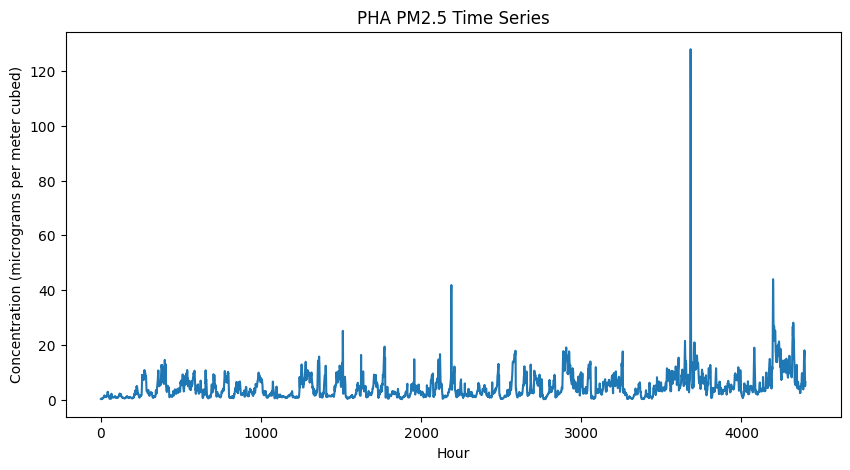

In [45]:
pha_final["pm25"].plot(figsize=(10,5), title="PHA PM2.5 Time Series")
plt.xlabel("Hour")
plt.ylabel("Concentration (micrograms per meter cubed)")

plt.savefig("eda plots/PHA PM2.5 time series.png")
plt.show()

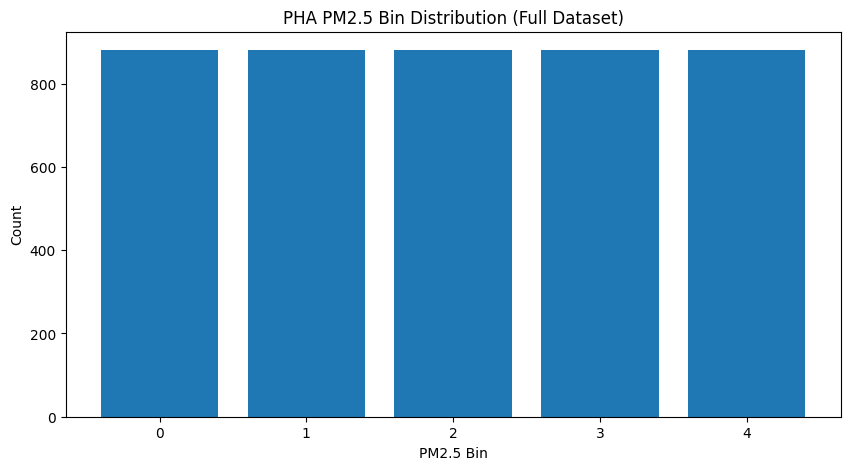

In [46]:
#PM2.5 bin distribution. For the time series we expect each bin to have equal counts
bin_counts = pha_final["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(bin_counts.index, bin_counts.values)

plt.xlabel("PM2.5 Bin")
plt.ylabel("Count")
plt.title("PHA PM2.5 Bin Distribution (Full Dataset)")
plt.xticks(bin_counts.index)

plt.savefig("eda plots/PHA PM2.5 bin distribution (full dataset).png")
plt.show()

In [47]:
pha_final["month"] = pd.to_datetime(pha_final["datetime_utc"]).dt.month
pha_final["season"] = pha_final["month"].apply(get_season)

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_93918/3366386487.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  jf_counts = pha_final[pema_final["season"] == "JF"]["pm25_bin"].value_counts().sort_index()


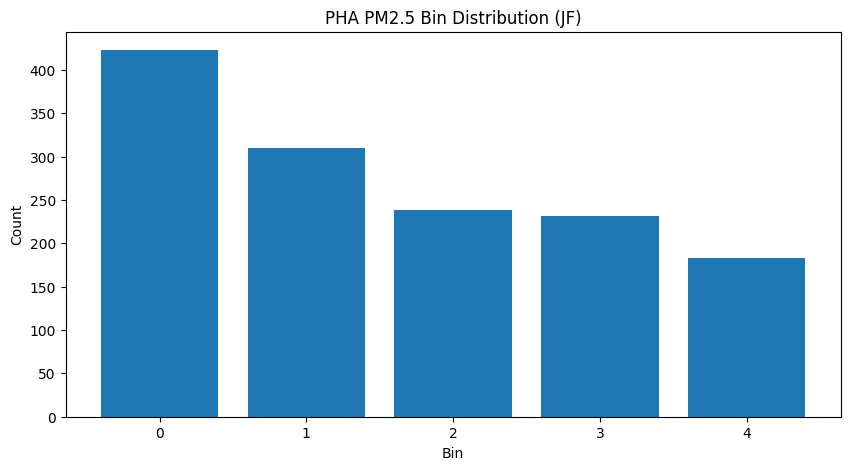

In [48]:
#plotting winter month bin counts
jf_counts = pha_final[pema_final["season"] == "JF"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(jf_counts.index, jf_counts.values)
plt.title("PHA PM2.5 Bin Distribution (JF)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(jf_counts.index)

plt.savefig("eda plots/PHA PM2.5 bin distribution (JF).png")
plt.show()

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_93918/224485639.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mam_counts = pha_final[pema_final["season"] == "MAM"]["pm25_bin"].value_counts().sort_index()


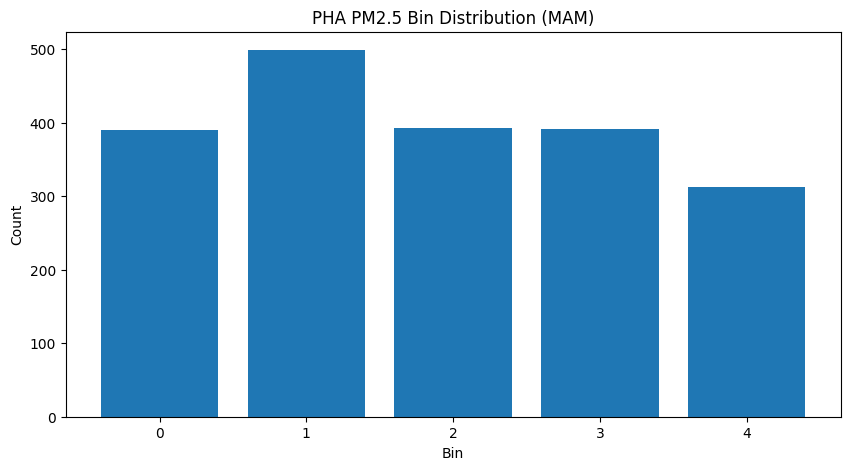

In [49]:
#plotting spring bin counts
mam_counts = pha_final[pema_final["season"] == "MAM"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(mam_counts.index, mam_counts.values)
plt.title("PHA PM2.5 Bin Distribution (MAM)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(mam_counts.index)

plt.savefig("eda plots/PHA PM2.5 bin distribution (MAM).png")
plt.show()

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_93918/2769365297.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  jja_counts = pha_final[dpw_final["season"] == "JJA"]["pm25_bin"].value_counts().sort_index()


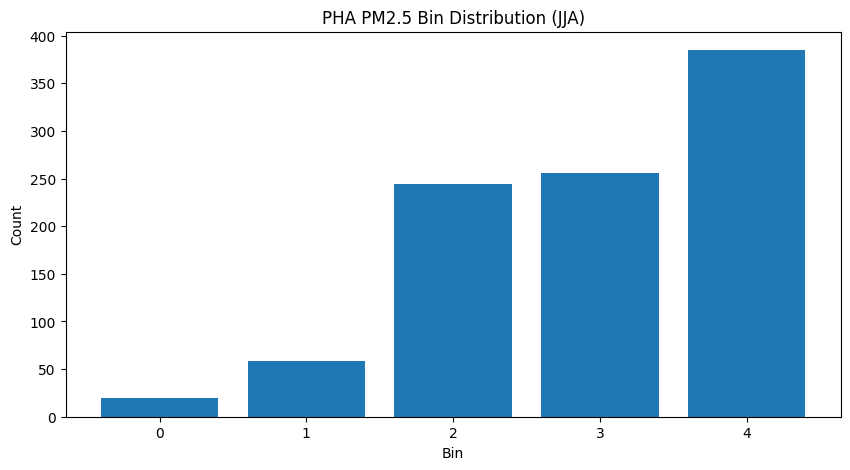

In [50]:
#plotting summer bin counts
jja_counts = pha_final[dpw_final["season"] == "JJA"]["pm25_bin"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(jja_counts.index, jja_counts.values)
plt.title("PHA PM2.5 Bin Distribution (JJA)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.xticks(jja_counts.index)

plt.savefig("eda plots/PHA PM2.5 bin distribution (JJA).png")
plt.show()

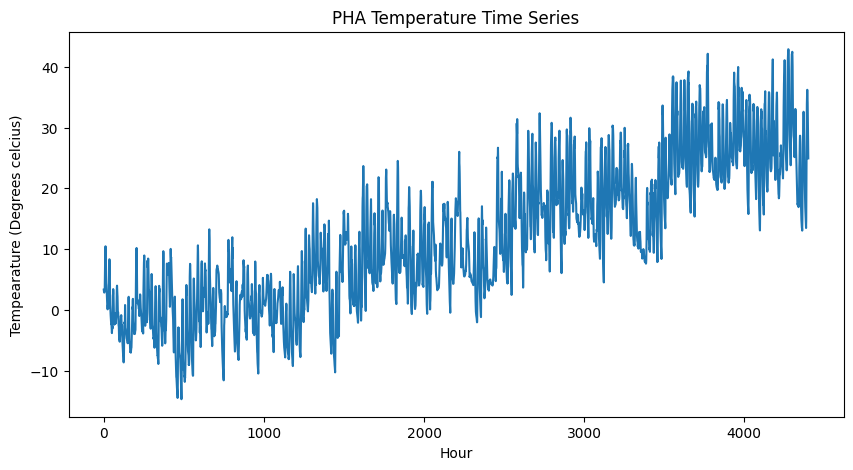

In [51]:
pha_final["temp"].plot(figsize=(10,5), title="PHA Temperature Time Series")
plt.xlabel("Hour")
plt.ylabel("Tempearature (Degrees celcius)")

plt.savefig("eda plots/PHA temperature time series.png")
plt.show()

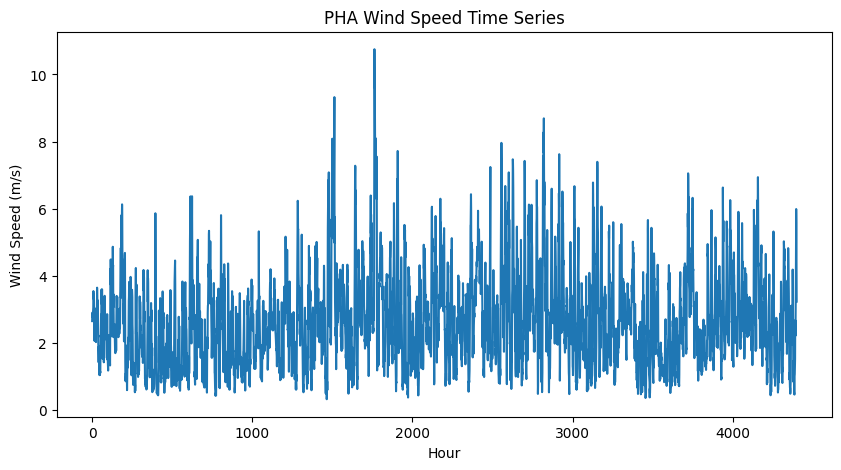

In [52]:
#time series for wind speed
pha_final["ws"].plot(figsize=(10,5), title="PHA Wind Speed Time Series")
plt.xlabel("Hour")
plt.ylabel("Wind Speed (m/s)")

plt.savefig("eda plots/PHA wind speed time series.png")
plt.show()

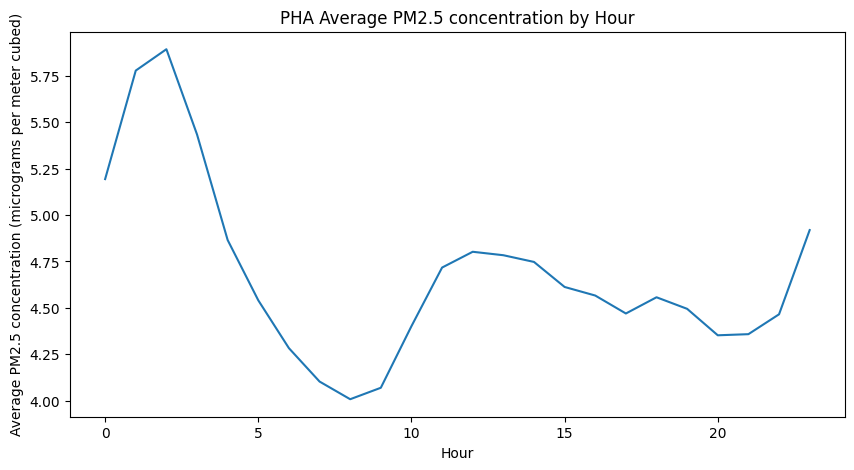

In [53]:
pha_hourly_pm = pha_final.groupby("hour")["pm25"].mean()

plt.figure(figsize=(10,5))
pha_hourly_pm.plot()
plt.title("PHA Average PM2.5 concentration by Hour")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5 concentration (micrograms per meter cubed)")

plt.savefig("eda plots/PHA average hourly PM2.5 concentration.png")
plt.show()

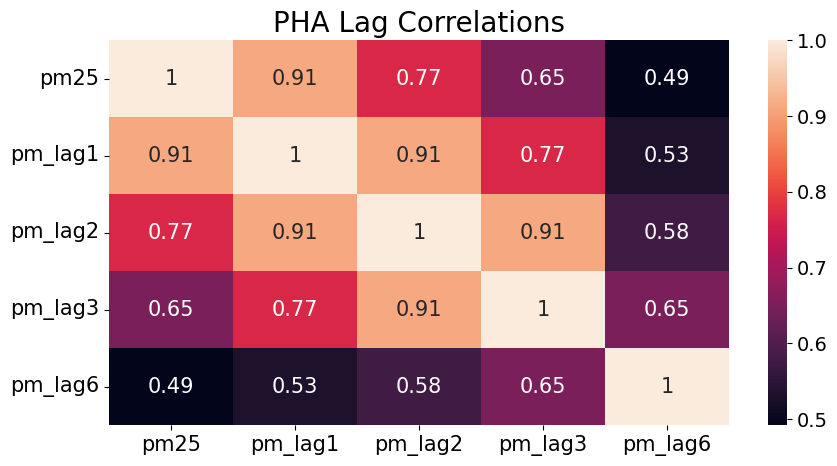

In [54]:
#correlation between various pm lags and pm itself
lags = ["pm25", "pm_lag1", "pm_lag2", "pm_lag3", "pm_lag6"]

plt.figure(figsize=(10,5))
ax = sns.heatmap(pha_final[lags].corr(), annot=True, annot_kws={"size": 15})
plt.title("PHA Lag Correlations", fontsize=20)
plt.yticks(rotation=0)

ax.tick_params(axis="both", labelsize=15)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.savefig("eda plots/PHA lag correlations.png")
plt.show()

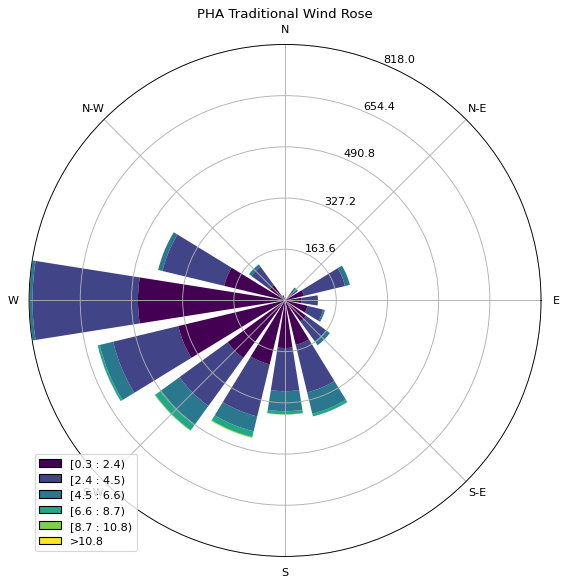

In [55]:
ax = WindroseAxes.from_ax()
ax.bar(pha_final["wd"], pha_final["ws"])
plt.title("PHA Traditional Wind Rose")
plt.legend()

plt.savefig("eda plots/PHA traditional wind rose.png")
plt.show()

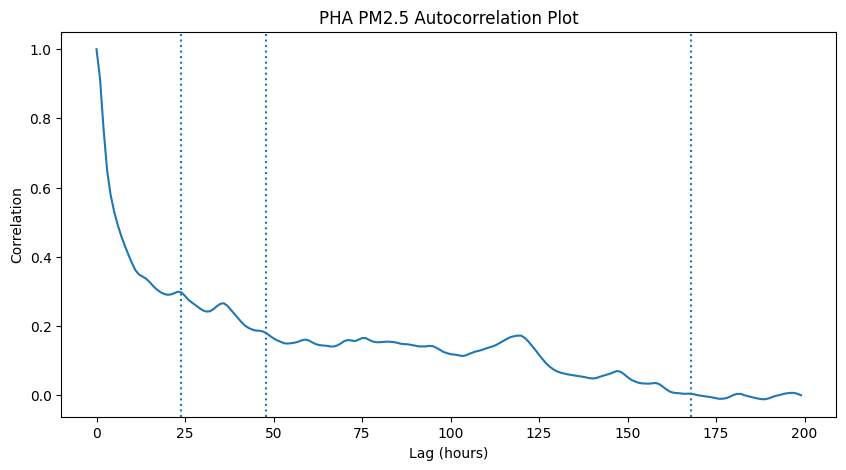

In [56]:
#only want lags over course of about a week here
#plot that was for whole time series did not show that much useful information
lags = range(0, 200)
acf_vals = []
for l in lags:
    val = pha_final["pm25"].autocorr(lag=l)
    acf_vals.append(val)

plt.figure(figsize=(10,5))
plt.title("PHA PM2.5 Autocorrelation Plot")

#plot lines where correlation may spike
plt.axvline(24, linestyle=":")
plt.axvline(48, linestyle=":")
plt.axvline(168, linestyle=":")

plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")

plt.savefig("eda plots/PHA PM2.5 autocorrelation plot.png")
plt.plot(lags, acf_vals)